# Primordial Single-Set Test (8 TeV)
Band + binned results from one formation-time scheme, using **eloss optical Glauber** maps in primordial format.

- Keeps old notebooks untouched
- Color convention: Pert = blue, NPWLC = green

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

project = Path.cwd()
if not (project / 'primordial_code').exists():
    project = project.parent

sys.path.insert(0, str(project))
sys.path.insert(0, str(project / 'primordial_code'))
sys.path.insert(0, str(project / 'primordial_notebooks'))

import primordial_only_eloss_glauber_test as prim
from primordial_module import ReaderConfig, Style, make_bins_from_width


In [2]:
ENERGY = '8.16'
FORM = 'new'
SELECT_MODELS = ('Pert', 'NPWLC')
SAVE_PDF = False
SAVE_CSV = False

Style.apply()
mpl.rcParams.update({
    'font.size': 11,
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'legend.frameon': True,
    'legend.framealpha': 0.85,
    'axes.unicode_minus': False,
})

Y_BINS = make_bins_from_width(-5.0, 5.0, 0.5)
PT_BINS = make_bins_from_width(0.0, 20.0, 2.5)
PT_WINDOW = (0.0, 15.0)
CENT_CLASSES = [(0,10),(10,20),(20,40),(40,60),(60,80),(80,100)]

prim.MODEL_COLORS['Pert'] = 'tab:blue'
prim.MODEL_COLORS['NPWLC'] = 'tab:green'


In [3]:
sqrts_gev = 8160.0 if ENERGY == '8.16' else 5020.0
glauber_root = project / 'primordial_output' / 'glauber_data' / ('8TeV_eloss' if ENERGY == '8.16' else '5TeV_eloss')
prim.generate_primordial_glauber_maps(
    glauber_root,
    cfg=prim.GlauberBridgeConfig(roots_gev=sqrts_gev, target_a=208, system='pA', bmax_fm=20.0, nb=401, include_npart=True, verbose=False),
)
prim._validate_glauber_maps(glauber_root)
print('[ok] generated maps:', glauber_root)

[ok] generated maps: /home/sawin/Desktop/Charmonia/charmonia_combined_analysis/primordial_output/glauber_data/8TeV_eloss


In [4]:
cfg = ReaderConfig(debug=False)
combos = prim._load_primordial_combos(ENERGY, FORM, glauber_root, cfg)
combos = [c for c in combos if c.model in SELECT_MODELS]
assert combos, 'No combos loaded'
pd.DataFrame([{
    'model': c.model, 'form': c.form, 'n_runs': len(c.runs), 'run_tags': ','.join(sorted(c.runs.keys()))
} for c in combos])

,model,form,n_runs,run_tags
0,Pert,new,2,"lower_binding,upper_binding"
1,NPWLC,new,2,"lower_binding,upper_binding"


In [5]:
for c in combos:
    maps = prim._maps_from_runs(c.runs)
    probe = maps.b_to_nbin(np.array([0.0, 2.0, 4.0], dtype=float))
    assert np.all(np.isfinite(probe)), f'Non-finite nbin probe for {c.model}: {probe}'
    print(f"[ok] {c.model} nbin(b=0,2,4) = {probe[0]:.3f}, {probe[1]:.3f}, {probe[2]:.3f}")

[ok] Pert nbin(b=0,2,4) = 15.498, 14.688, 11.829
[ok] NPWLC nbin(b=0,2,4) = 15.498, 14.688, 11.829


In [6]:
res_y = {}
res_pt = {}
for c in combos:
    center_y, band_y = c.ens.central_and_band_vs_y(pt_window=PT_WINDOW, y_bins=Y_BINS, with_feeddown=True, use_nbin=True, flip_y=True)
    center_pt, band_pt = c.ens.central_and_band_vs_pt(y_window=prim.Y_WINDOWS['central'], pt_bins=PT_BINS, with_feeddown=True, use_nbin=True)
    assert not center_y.empty and not center_pt.empty
    res_y[c.model] = (center_y, band_y)
    res_pt[c.model] = (center_pt, band_pt)
print('[ok] computed y and pT band+binned outputs')

[ok] computed y and pT band+binned outputs


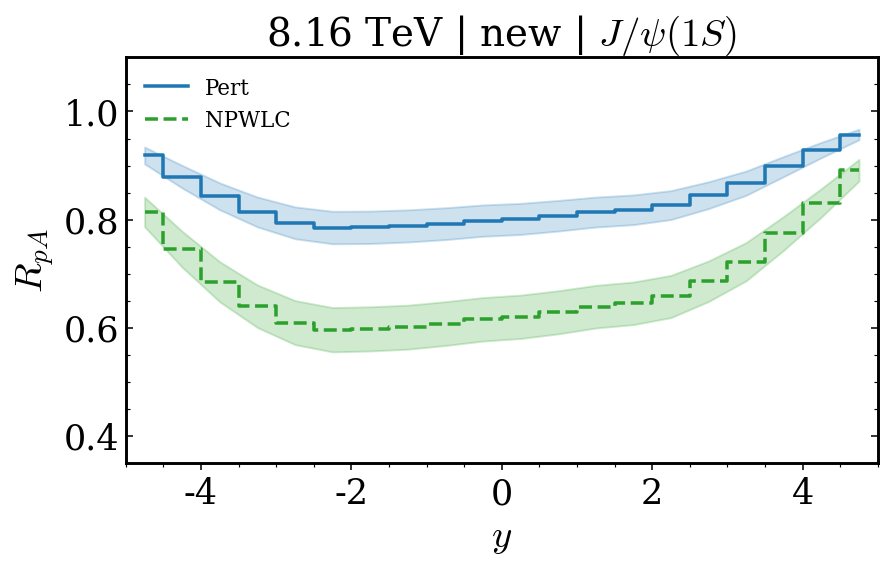

In [7]:
state = 'jpsi_1S'
fig, ax = plt.subplots(figsize=(6.5, 4.2), dpi=140)
for model in SELECT_MODELS:
    if model not in res_y:
        continue
    dc, db = res_y[model]
    x = dc['y'].to_numpy(float)
    y = dc[state].to_numpy(float)
    ax.step(x, y, where='mid', lw=1.8, color=prim.MODEL_COLORS[model], ls=prim.MODEL_LS[model], label=model)
    if db is not None and f'{state}_lo' in db.columns:
        ax.fill_between(db['y'].to_numpy(float), db[f'{state}_lo'].to_numpy(float), db[f'{state}_hi'].to_numpy(float), alpha=0.22, color=prim.MODEL_COLORS[model])
ax.set_xlabel(r'$y$')
ax.set_ylabel(r'$R_{pA}$')
ax.set_title(f'8.16 TeV | {FORM} | {prim.STATE_LABELS[state]}')
ax.set_xlim(-5, 5)
ax.set_ylim(0.35, 1.1)
ax.minorticks_on()
ax.tick_params(axis='y', which='major', direction='in', right=True)
ax.tick_params(axis='y', which='minor', direction='in', right=True)
ax.grid(False)
ax.legend(frameon=False)
plt.show()

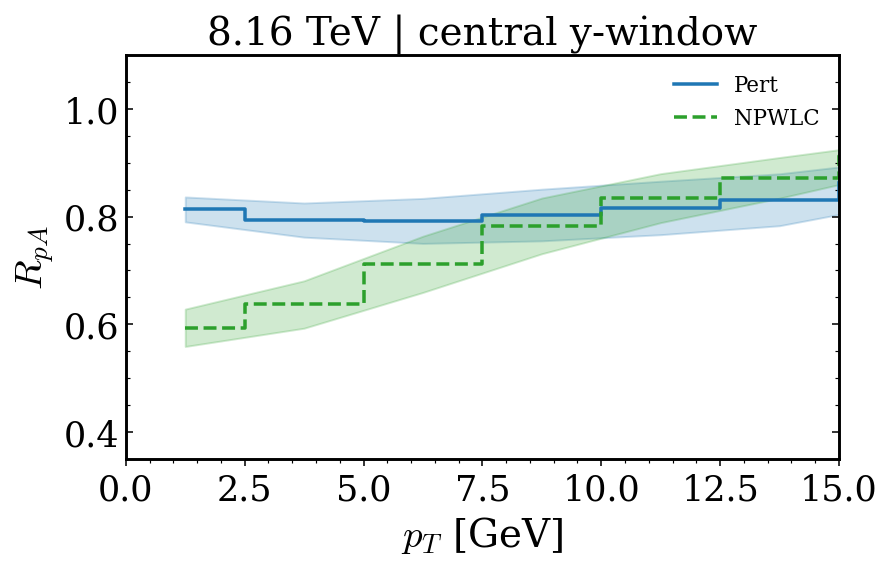

In [8]:
state = 'jpsi_1S'
fig, ax = plt.subplots(figsize=(6.5, 4.2), dpi=140)
for model in SELECT_MODELS:
    if model not in res_pt:
        continue
    dc, db = res_pt[model]
    x = dc['pt'].to_numpy(float)
    y = dc[state].to_numpy(float)
    ax.step(x, y, where='mid', lw=1.8, color=prim.MODEL_COLORS[model], ls=prim.MODEL_LS[model], label=model)
    if db is not None and f'{state}_lo' in db.columns:
        ax.fill_between(db['pt'].to_numpy(float), db[f'{state}_lo'].to_numpy(float), db[f'{state}_hi'].to_numpy(float), alpha=0.22, color=prim.MODEL_COLORS[model])
ax.set_xlabel(r'$p_T$ [GeV]')
ax.set_ylabel(r'$R_{pA}$')
ax.set_title(r'8.16 TeV | central y-window')
ax.set_xlim(0, 15)
ax.set_ylim(0.35, 1.1)
ax.minorticks_on()
ax.tick_params(axis='y', which='major', direction='in', right=True)
ax.tick_params(axis='y', which='minor', direction='in', right=True)
ax.grid(False)
ax.legend(frameon=False)
plt.show()